In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(
    r"C:\Users\ASUS\OneDrive\Desktop\Ecommerce-Sales-Profitability-Analysis\data\cleaned\ecommerce_orders_cleaned.csv"
)

df.head()

,Order_ID,Customer_ID,Order_Date,Year,Month,Day,Day_Of_Week,Quarter,Customer_Age,Customer_Gender,...,Delivery_Days,Order_Status,Returned,Review_Rating,Customer_Lifetime_Value,Profit_Margin_Percent,Profit_Amount,Season,Holiday_Season,High_Value_Order
0,615717,CUST007322,2023-01-01,2023,1,1,Sunday,1,32,Male,...,2,Delivered,No,4.4,2144.92,23.10,15.75,Winter,No,No
1,626919,CUST004717,2023-01-01,2023,1,1,Sunday,1,50,Male,...,9,Delivered,No,4.1,817.17,8.57,3.32,Winter,No,No
2,615781,CUST004415,2023-01-01,2023,1,1,Sunday,1,61,Male,...,2,Delivered,No,5.0,541.16,29.72,45.67,Winter,No,No
3,621747,CUST004114,2023-01-01,2023,1,1,Sunday,1,34,Male,...,6,Returned,Yes,3.4,700.49,25.22,75.25,Winter,No,No
4,625881,CUST000145,2023-01-01,2023,1,1,Sunday,1,37,Male,...,8,Delivered,No,3.6,2133.77,24.64,26.06,Winter,No,No


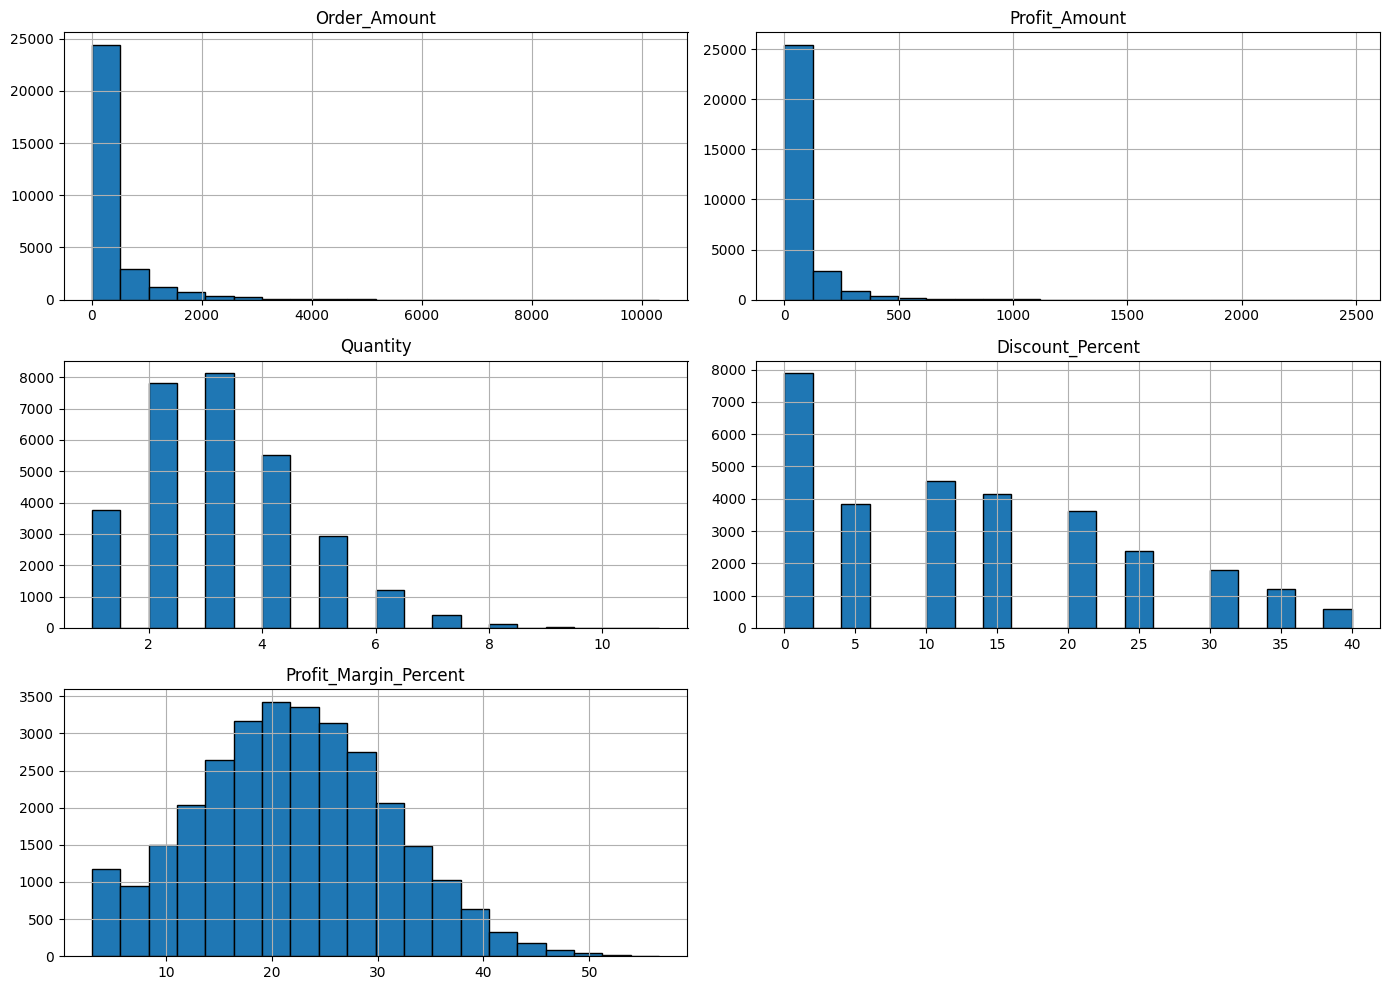

In [2]:
numerical_columns = [
    "Order_Amount",
    "Profit_Amount",
    "Quantity",
    "Discount_Percent",
    "Profit_Margin_Percent"
]

df[numerical_columns].hist(
    figsize=(14, 10),
    bins=20,
    edgecolor="black"
)

plt.tight_layout()
plt.show()

In [3]:
categorical_columns = [
    "Product_Category",
    "Customer_Segment",
    "Customer_Gender",
    "Order_Status"
]

for column in categorical_columns:
    print(f"\nDistribution of {column}:")
    print(df[column].value_counts())


Distribution of Product_Category:
Product_Category
Fashion           6092
Groceries         5380
Electronics       4699
Home & Kitchen    4194
Beauty            2971
Sports            2439
Books             2163
Toys              2062
Name: count, dtype: int64

Distribution of Customer_Segment:
Customer_Segment
Returning    11987
New           7794
Loyal         7214
Premium       3005
Name: count, dtype: int64

Distribution of Customer_Gender:
Customer_Gender
Female    14863
Male      14552
Other       585
Name: count, dtype: int64

Distribution of Order_Status:
Order_Status
Delivered     19497
Shipped        3469
Returned       3033
Processing     2230
Cancelled      1771
Name: count, dtype: int64


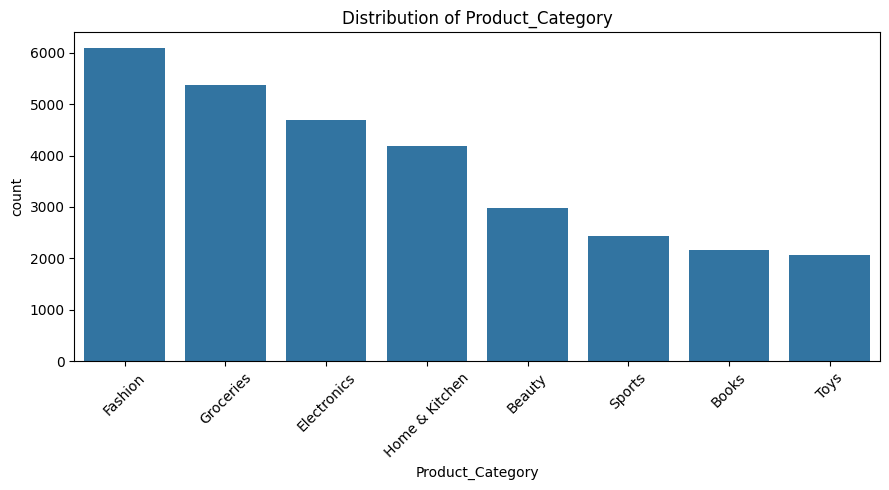

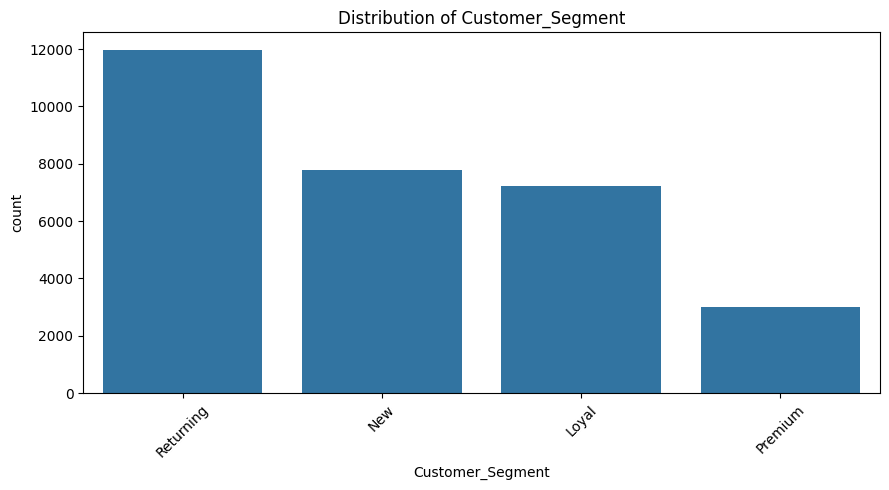

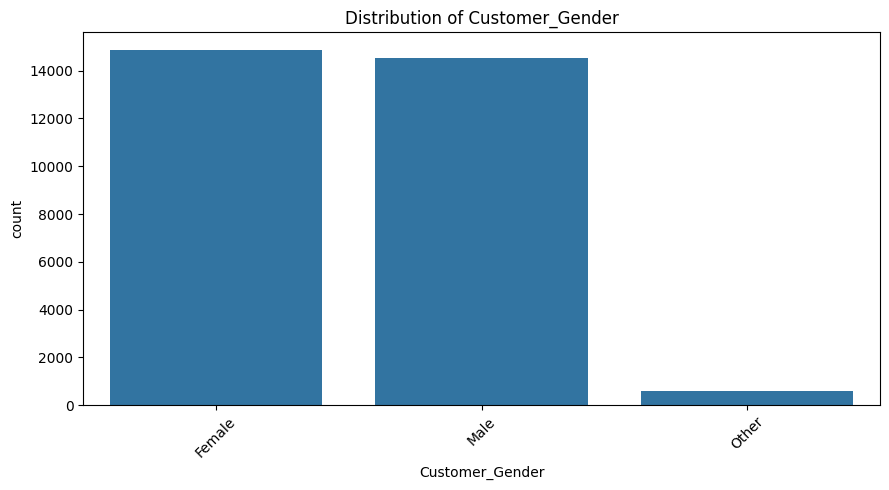

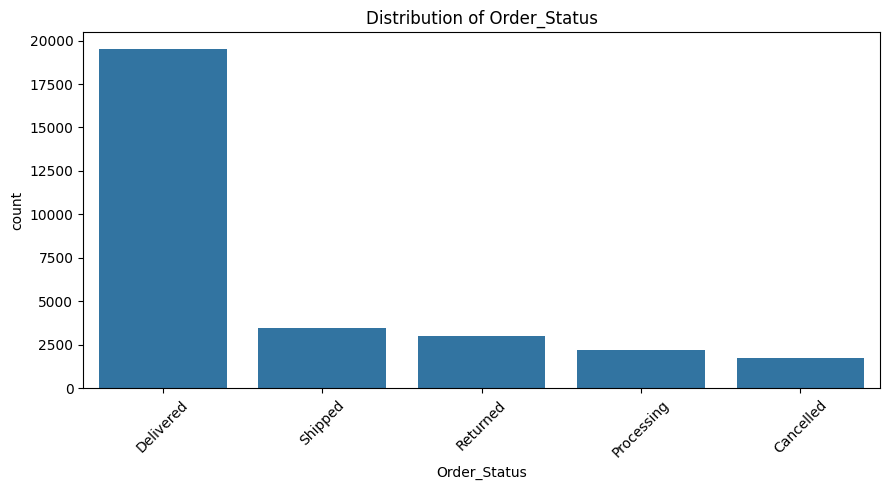

In [4]:
for column in categorical_columns:
    plt.figure(figsize=(9, 5))

    sns.countplot(
        data=df,
        x=column,
        order=df[column].value_counts().index
    )

    plt.title(f"Distribution of {column}")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [5]:
category_analysis = (
    df.groupby("Product_Category")
      .agg(
          Total_Revenue=("Order_Amount", "sum"),
          Total_Profit=("Profit_Amount", "sum"),
          Average_Profit=("Profit_Amount", "mean")
      )
      .sort_values("Total_Revenue", ascending=False)
)

display(category_analysis)

,Total_Revenue,Total_Profit,Average_Profit
Product_Category,,,
Electronics,6320059.31,1040688.00,221.470100
Home & Kitchen,1768963.43,379418.20,90.466905
Fashion,1323929.17,344642.74,56.573004
Sports,661447.69,139758.27,57.301464
Beauty,460243.32,134401.18,45.237691
Groceries,360727.15,76057.26,14.137037
Toys,279307.23,60150.95,29.171169
Books,195366.69,40799.67,18.862538


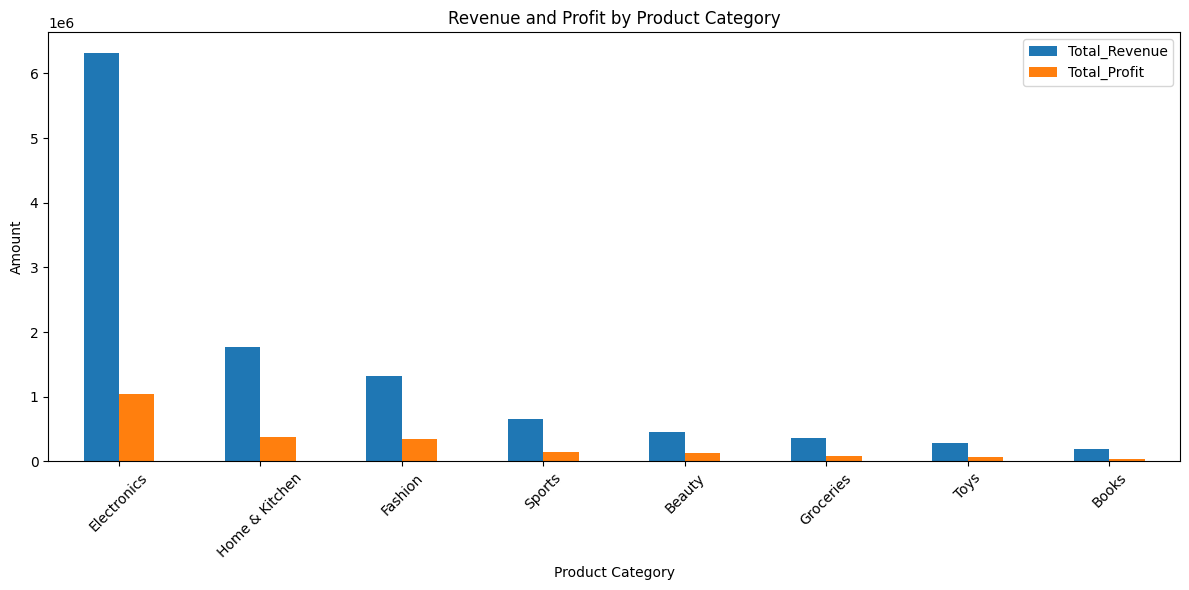

In [6]:
category_analysis[["Total_Revenue", "Total_Profit"]].plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Revenue and Profit by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Amount")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

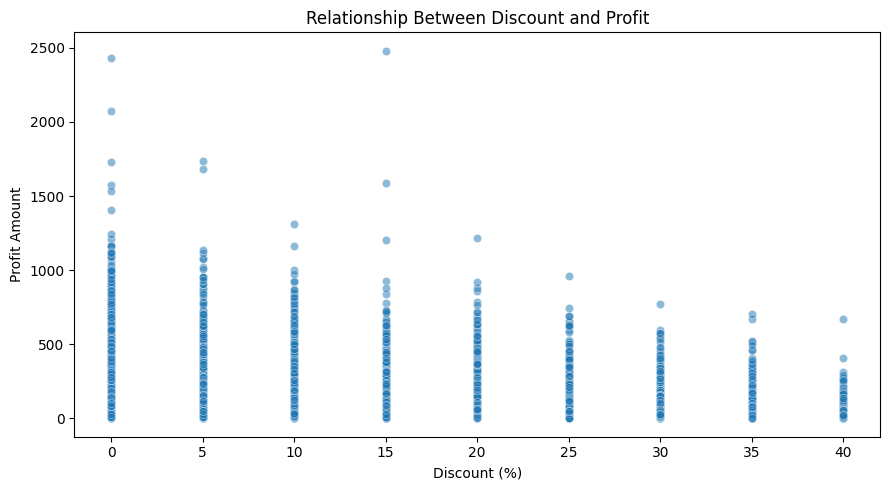

In [7]:
plt.figure(figsize=(9, 5))

sns.scatterplot(
    data=df,
    x="Discount_Percent",
    y="Profit_Amount",
    alpha=0.5
)

plt.title("Relationship Between Discount and Profit")
plt.xlabel("Discount (%)")
plt.ylabel("Profit Amount")
plt.tight_layout()
plt.show()

In [8]:
segment_analysis = (
    df.groupby("Customer_Segment")
      .agg(
          Total_Revenue=("Order_Amount", "sum"),
          Total_Profit=("Profit_Amount", "sum"),
          Average_Order_Value=("Order_Amount", "mean"),
          Order_Count=("Order_ID", "nunique")
      )
      .sort_values("Total_Revenue", ascending=False)
)

display(segment_analysis)

,Total_Revenue,Total_Profit,Average_Order_Value,Order_Count
Customer_Segment,,,,
Returning,4582714.19,888003.26,382.307015,11987
New,2982575.91,579346.30,382.675893,7794
Loyal,2659608.61,526075.50,368.673220,7214
Premium,1145145.28,222491.21,381.079960,3005


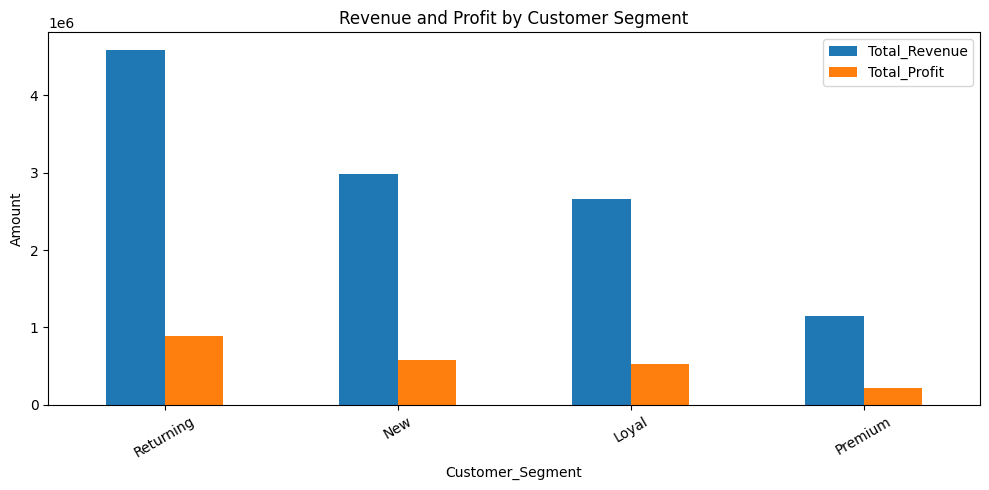

In [9]:
segment_analysis[["Total_Revenue", "Total_Profit"]].plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Revenue and Profit by Customer Segment")
plt.ylabel("Amount")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [10]:
df["Order_Date"] = pd.to_datetime(
    df["Order_Date"],
    errors="coerce"
)

print("Invalid or missing dates:", df["Order_Date"].isna().sum())

Invalid or missing dates: 0


In [11]:
df["Year_Month"] = df["Order_Date"].dt.to_period("M")

monthly_analysis = (
    df.dropna(subset=["Order_Date"])
      .groupby("Year_Month")
      .agg(
          Total_Revenue=("Order_Amount", "sum"),
          Total_Profit=("Profit_Amount", "sum")
      )
)

display(monthly_analysis)

,Total_Revenue,Total_Profit
Year_Month,,
2023-01,286490.57,55697.86
2023-02,253970.94,49578.51
2023-03,269086.84,54753.15
2023-04,208666.60,43798.44
2023-05,237289.67,45893.57
2023-06,234097.27,47622.28
2023-07,224420.24,43827.34
2023-08,272804.15,51646.29
2023-09,238898.61,43080.10


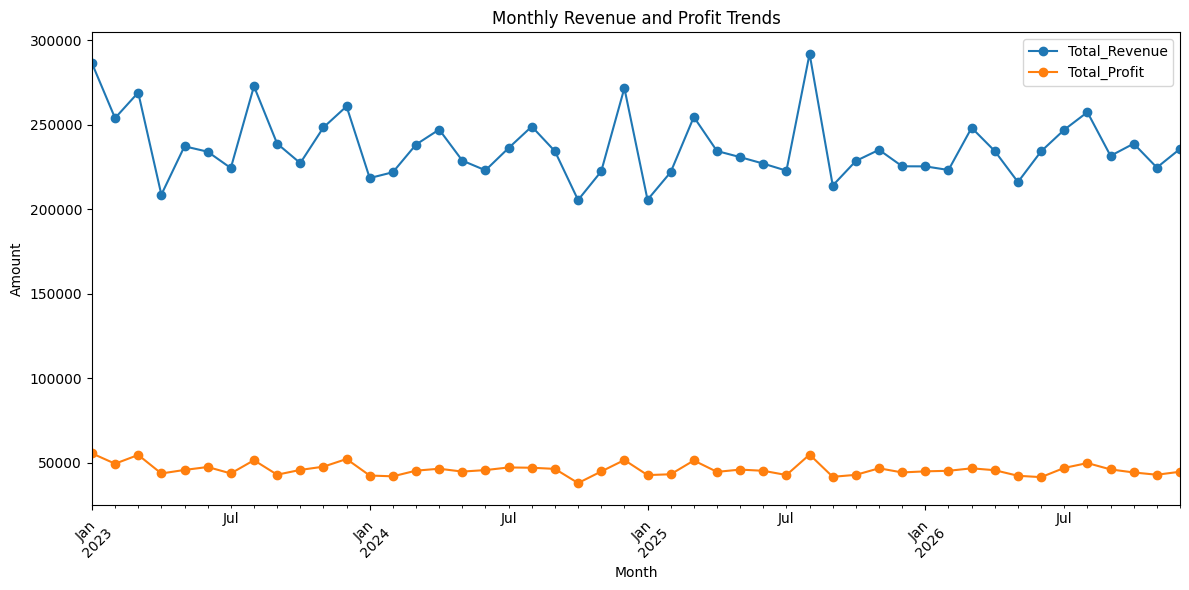

In [12]:
monthly_analysis.plot(
    y=["Total_Revenue", "Total_Profit"],
    figsize=(12, 6),
    marker="o"
)

plt.title("Monthly Revenue and Profit Trends")
plt.xlabel("Month")
plt.ylabel("Amount")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [13]:
numerical_df = df.select_dtypes(include="number")

correlation_matrix = numerical_df.corr()

display(correlation_matrix.round(2))

,Order_ID,Year,Month,Day,Quarter,Customer_Age,Unit_Price,Quantity,Discount_Percent,Discount_Amount,Shipping_Cost,Tax_Amount,Order_Amount,Delivery_Days,Review_Rating,Customer_Lifetime_Value,Profit_Margin_Percent,Profit_Amount
Order_ID,1.00,-0.00,-0.01,0.00,-0.01,-0.00,-0.00,-0.01,0.01,-0.00,-0.00,-0.00,-0.00,-0.00,0.00,-0.01,-0.01,-0.01
Year,-0.00,1.00,0.00,-0.01,0.00,0.00,-0.00,-0.01,0.00,-0.00,-0.00,-0.01,-0.01,-0.00,0.01,-0.01,-0.01,-0.01
Month,-0.01,0.00,1.00,0.01,0.97,-0.01,-0.01,0.01,0.01,0.01,-0.00,0.00,-0.00,0.00,-0.01,0.00,-0.00,-0.01
Day,0.00,-0.01,0.01,1.00,0.01,-0.00,-0.01,-0.01,0.00,-0.01,-0.01,-0.01,-0.01,0.00,0.00,-0.01,0.00,-0.01
Quarter,-0.01,0.00,0.97,0.01,1.00,-0.01,-0.01,0.01,0.01,0.01,-0.00,0.00,-0.00,0.00,-0.01,0.00,-0.00,-0.01
Customer_Age,-0.00,0.00,-0.01,-0.00,-0.01,1.00,-0.00,-0.01,0.00,0.00,0.00,-0.00,-0.00,-0.00,0.00,-0.00,-0.00,-0.01
Unit_Price,-0.00,-0.00,-0.01,-0.01,-0.01,-0.00,1.00,-0.01,0.00,0.60,-0.00,0.80,0.85,0.01,0.00,0.76,-0.23,0.70
Quantity,-0.01,-0.01,0.01,-0.01,0.01,-0.01,-0.01,1.00,0.00,0.20,0.29,0.27,0.29,0.00,-0.00,0.26,0.00,0.29
Discount_Percent,0.01,0.00,0.01,0.00,0.01,0.00,0.00,0.00,1.00,0.39,-0.00,0.00,-0.07,0.01,0.00,-0.06,-0.29,-0.15
Discount_Amount,-0.00,-0.00,0.01,-0.01,0.01,0.00,0.60,0.20,0.39,1.00,0.06,0.64,0.59,0.00,-0.00,0.52,-0.25,0.38


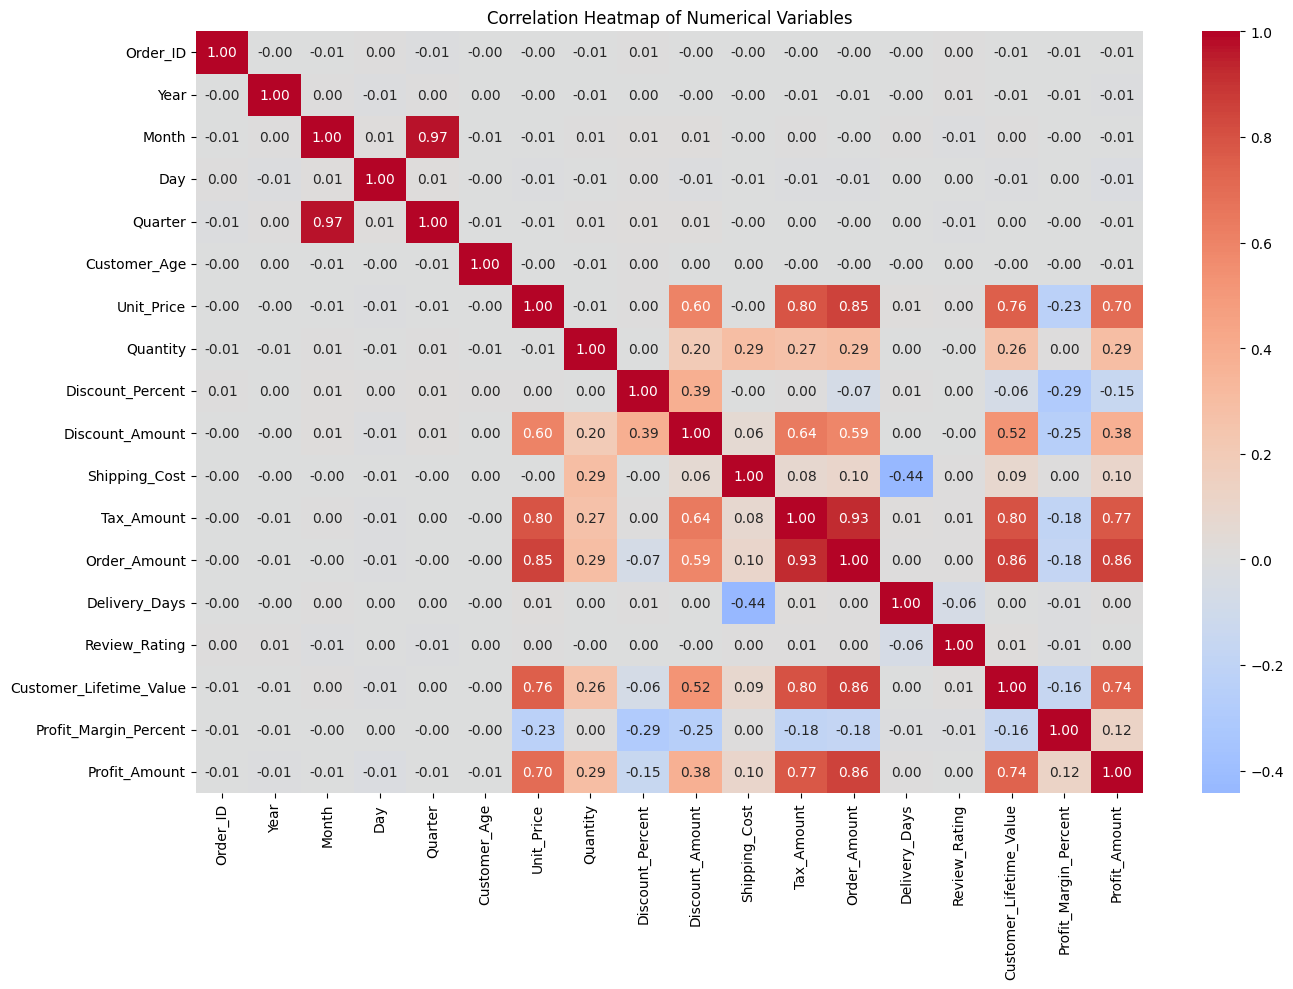

In [14]:
plt.figure(figsize=(14, 10))

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0,
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Heatmap of Numerical Variables")
plt.tight_layout()
plt.show()

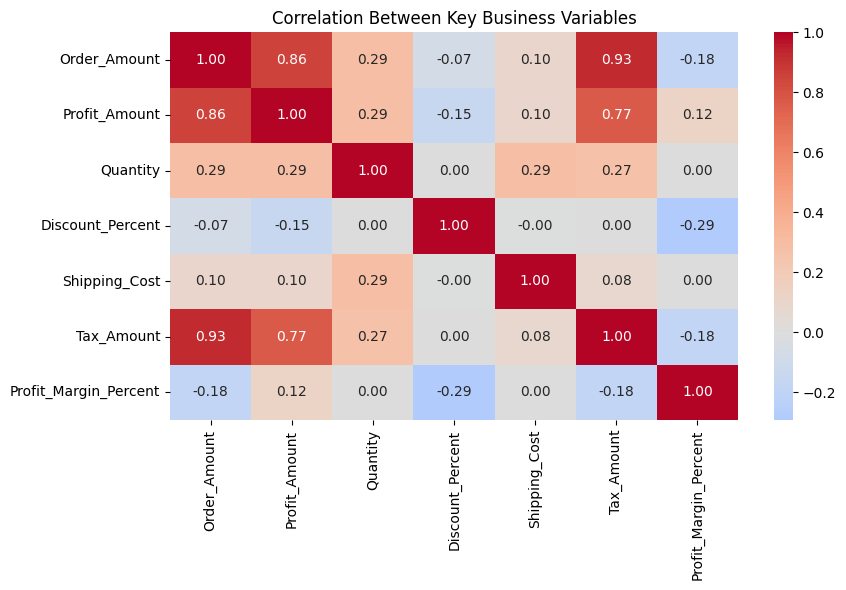

In [15]:
selected_columns = [
    "Order_Amount",
    "Profit_Amount",
    "Quantity",
    "Discount_Percent",
    "Shipping_Cost",
    "Tax_Amount",
    "Profit_Margin_Percent"
]

selected_columns = [
    col for col in selected_columns if col in df.columns
]

plt.figure(figsize=(9, 6))

sns.heatmap(
    df[selected_columns].corr(),
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f"
)

plt.title("Correlation Between Key Business Variables")
plt.tight_layout()
plt.show()

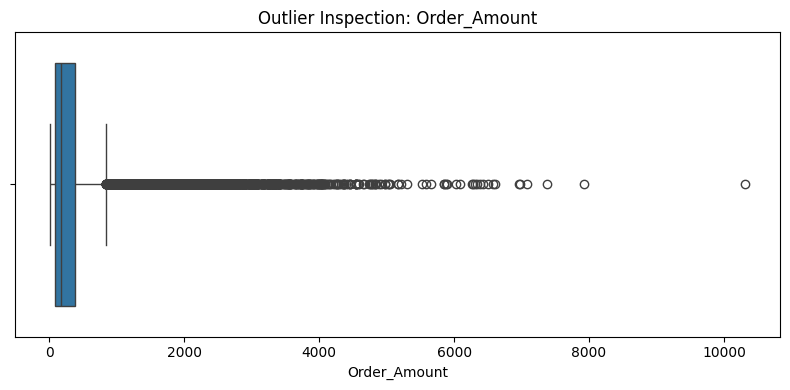

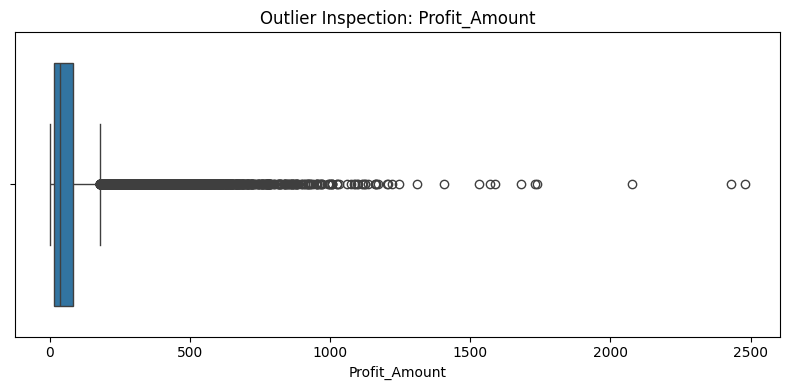

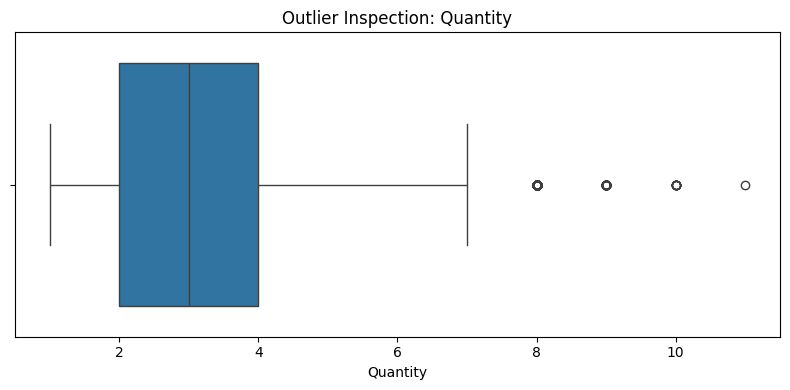

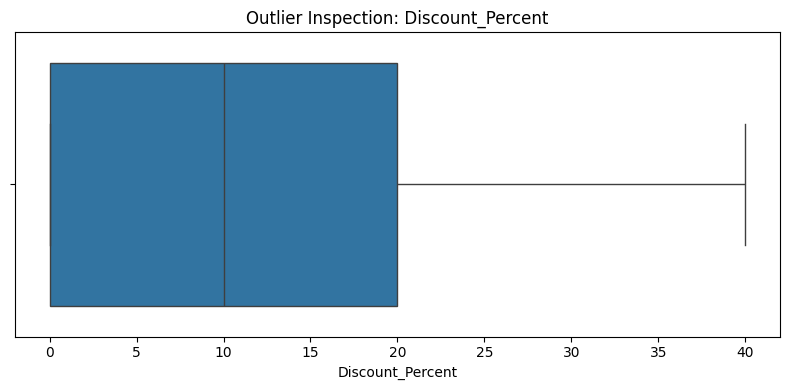

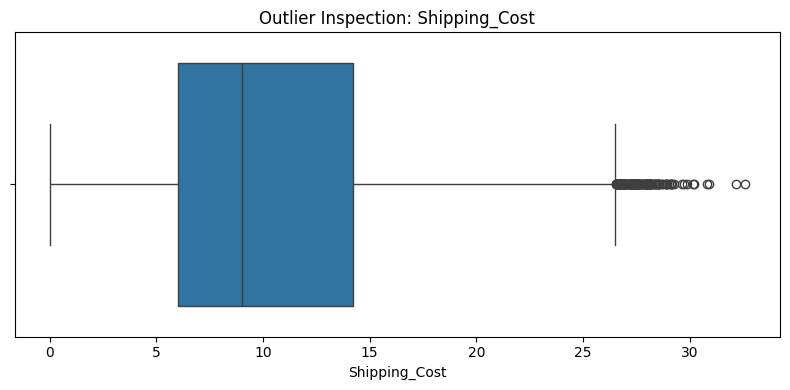

In [16]:
outlier_columns = [
    "Order_Amount",
    "Profit_Amount",
    "Quantity",
    "Discount_Percent",
    "Shipping_Cost"
]

outlier_columns = [
    col for col in outlier_columns if col in df.columns
]

for column in outlier_columns:
    plt.figure(figsize=(8, 4))

    sns.boxplot(x=df[column])

    plt.title(f"Outlier Inspection: {column}")
    plt.tight_layout()
    plt.show()

In [17]:
for column in outlier_columns:
    values = df[column].dropna()

    q1 = values.quantile(0.25)
    q3 = values.quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outliers = values[
        (values < lower_bound) | (values > upper_bound)
    ]

    print(f"\nColumn: {column}")
    print("Potential outliers:", len(outliers))
    print("Lower bound:", round(lower_bound, 2))
    print("Upper bound:", round(upper_bound, 2))


Column: Order_Amount
Potential outliers: 3446
Lower bound: -374.92
Upper bound: 846.05

Column: Profit_Amount
Potential outliers: 2796
Lower bound: -81.59
Upper bound: 180.35

Column: Quantity
Potential outliers: 179
Lower bound: -1.0
Upper bound: 7.0

Column: Discount_Percent
Potential outliers: 0
Lower bound: -30.0
Upper bound: 50.0

Column: Shipping_Cost
Potential outliers: 164
Lower bound: -6.28
Upper bound: 26.52


In [18]:
print("EDA SUMMARY")
print("-" * 40)

print("Total records:", len(df))
print("Total columns:", len(df.columns))

print("\nMissing values:")
print(df.isnull().sum()[df.isnull().sum() > 0])

print("\nNumerical summary:")
display(df.describe().round(2))

print("\nTop product categories by record count:")
print(df["Product_Category"].value_counts().head())

print("\nCustomer segment distribution:")
print(df["Customer_Segment"].value_counts())

EDA SUMMARY
----------------------------------------
Total records: 30000
Total columns: 42

Missing values:
Series([], dtype: int64)

Numerical summary:


,Order_ID,Order_Date,Year,Month,Day,Quarter,Customer_Age,Unit_Price,Quantity,Discount_Percent,Discount_Amount,Shipping_Cost,Tax_Amount,Order_Amount,Delivery_Days,Review_Rating,Customer_Lifetime_Value,Profit_Margin_Percent,Profit_Amount
count,30000.00,30000,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00
mean,615000.50,2024-12-29 10:37:23.520000,2024.49,6.53,15.72,2.51,36.37,126.82,3.08,12.62,49.43,10.32,29.14,379.00,4.44,4.05,4372.34,21.97,73.86
min,600001.00,2023-01-01 00:00:00,2023.00,1.00,1.00,1.00,18.00,3.84,1.00,0.00,0.00,0.00,0.26,6.67,0.00,1.00,20.00,3.00,0.27
25%,607500.75,2023-12-27 18:00:00,2023.00,4.00,8.00,2.00,28.00,29.88,2.00,0.00,0.00,6.02,5.27,82.95,3.00,3.60,1029.64,15.68,16.64
50%,615000.50,2024-12-30 00:00:00,2024.00,7.00,16.00,3.00,36.00,60.67,3.00,10.00,13.47,9.00,12.07,171.03,4.00,4.10,2073.36,21.87,37.00
75%,622500.25,2025-12-29 00:00:00,2025.00,10.00,23.00,4.00,44.00,128.57,4.00,20.00,44.82,14.22,29.44,388.19,6.00,4.60,4482.10,28.18,82.12
max,630000.00,2026-12-31 00:00:00,2026.00,12.00,31.00,4.00,75.00,1940.00,11.00,40.00,2623.90,32.60,1043.16,10314.27,13.00,5.00,50000.00,56.61,2480.54
std,8660.40,NaN,1.12,3.46,8.78,1.12,11.32,172.68,1.45,11.09,114.40,5.89,49.56,585.41,2.35,0.69,6811.03,9.08,113.48



Top product categories by record count:
Product_Category
Fashion           6092
Groceries         5380
Electronics       4699
Home & Kitchen    4194
Beauty            2971
Name: count, dtype: int64

Customer segment distribution:
Customer_Segment
Returning    11987
New           7794
Loyal         7214
Premium       3005
Name: count, dtype: int64


## EDA Findings — E-Commerce Sales & Profitability Analysis

### 1. Dataset overview

Describe the number of records, columns, and the main types of information available.

### 2. Sales and profit distribution

Summarize the distribution of order amounts and profit amounts.

### 3. Product category patterns

Identify the categories with the highest revenue and highest profit.

### 4. Customer segment patterns

Explain which customer segments contribute most to revenue and profit.

### 5. Discount and profitability relationship

Describe the observed relationship between discounts and profit, without assuming causation.

### 6. Monthly trends

Identify months with relatively high or low revenue and profit, where supported by the data.

### 7. Correlations and outliers

Record notable numerical relationships and unusual values that deserve further investigation.

### 8. Conclusion

Summarize the most important patterns discovered and identify the business questions that should be investigated in the next phase.


In [19]:
# Identify records with negative profit
loss_df = df[df["Profit_Amount"] < 0].copy()

print("Total records:", len(df))
print("Loss-making records:", len(loss_df))
print("Percentage of records with losses:",
      round(len(loss_df) / len(df) * 100, 2), "%")

print("Total profit/loss from negative-profit records:",
      round(loss_df["Profit_Amount"].sum(), 2))

Total records: 30000
Loss-making records: 0
Percentage of records with losses: 0.0 %
Total profit/loss from negative-profit records: 0.0


In [20]:
category_loss = (
    df.groupby("Product_Category")
      .agg(
          Total_Revenue=("Order_Amount", "sum"),
          Total_Profit=("Profit_Amount", "sum"),
          Loss_Records=("Profit_Amount", lambda x: (x < 0).sum())
      )
      .sort_values("Total_Profit")
)

display(category_loss)

,Total_Revenue,Total_Profit,Loss_Records
Product_Category,,,
Books,195366.69,40799.67,0
Toys,279307.23,60150.95,0
Groceries,360727.15,76057.26,0
Beauty,460243.32,134401.18,0
Sports,661447.69,139758.27,0
Fashion,1323929.17,344642.74,0
Home & Kitchen,1768963.43,379418.20,0
Electronics,6320059.31,1040688.00,0


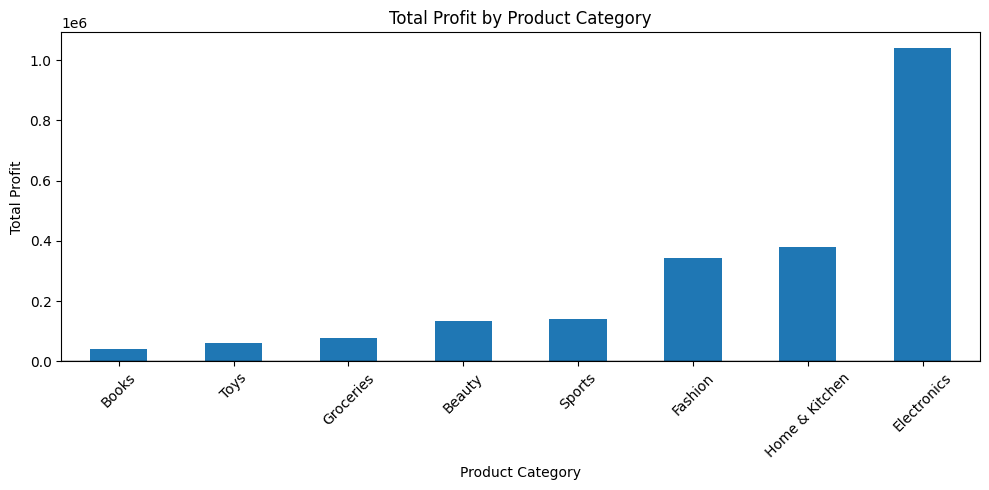

In [21]:
category_loss["Total_Profit"].plot(
    kind="bar",
    figsize=(10, 5)
)

plt.axhline(y=0, color="black", linewidth=1)
plt.title("Total Profit by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Profit")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [22]:
product_loss = (
    loss_df.groupby(["Product_ID", "Product_Category"])
           .agg(
               Loss_Amount=("Profit_Amount", "sum"),
               Loss_Records=("Profit_Amount", "count"),
               Average_Discount=("Discount_Percent", "mean"),
               Average_Shipping_Cost=("Shipping_Cost", "mean")
           )
           .sort_values("Loss_Amount")
)

display(product_loss.head(10))

,,Loss_Amount,Loss_Records,Average_Discount,Average_Shipping_Cost
Product_ID,Product_Category,,,,


In [23]:
df["Discount_Group"] = pd.cut(
    df["Discount_Percent"],
    bins=[-0.01, 10, 20, 30, 40],
    labels=["0–10%", "10–20%", "20–30%", "30–40%"]
)

discount_loss = (
    df.groupby("Discount_Group", observed=False)
      .agg(
          Records=("Profit_Amount", "size"),
          Total_Revenue=("Order_Amount", "sum"),
          Total_Profit=("Profit_Amount", "sum"),
          Average_Profit=("Profit_Amount", "mean"),
          Loss_Records=("Profit_Amount", lambda x: (x < 0).sum())
      )
)

discount_loss["Loss_Record_Percentage"] = (
    discount_loss["Loss_Records"] / discount_loss["Records"] * 100
)

display(discount_loss.round(2))

,Records,Total_Revenue,Total_Profit,Average_Profit,Loss_Records,Loss_Record_Percentage
Discount_Group,,,,,,
0–10%,16255,6666888.08,1423507.47,87.57,0,0.0
10–20%,7768,2826260.99,506446.16,65.20,0,0.0
20–30%,4184,1339573.09,213257.29,50.97,0,0.0
30–40%,1793,537321.83,72705.35,40.55,0,0.0


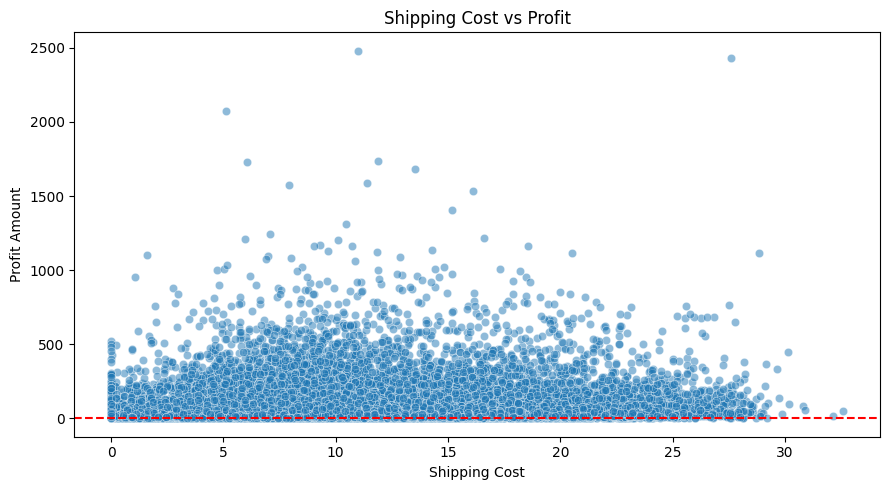

In [24]:
plt.figure(figsize=(9, 5))

sns.scatterplot(
    data=df,
    x="Shipping_Cost",
    y="Profit_Amount",
    alpha=0.5
)

plt.axhline(y=0, color="red", linestyle="--")
plt.title("Shipping Cost vs Profit")
plt.xlabel("Shipping Cost")
plt.ylabel("Profit Amount")
plt.tight_layout()
plt.show()

In [25]:
segment_loss = (
    df.groupby("Customer_Segment")
      .agg(
          Total_Profit=("Profit_Amount", "sum"),
          Loss_Records=("Profit_Amount", lambda x: (x < 0).sum()),
          Total_Records=("Profit_Amount", "size"),
          Average_Profit=("Profit_Amount", "mean")
      )
)

segment_loss["Loss_Percentage"] = (
    segment_loss["Loss_Records"] / segment_loss["Total_Records"] * 100
)

display(segment_loss.sort_values("Total_Profit").round(2))

,Total_Profit,Loss_Records,Total_Records,Average_Profit,Loss_Percentage
Customer_Segment,,,,,
Premium,222491.21,0,3005,74.04,0.0
Loyal,526075.50,0,7214,72.92,0.0
New,579346.30,0,7794,74.33,0.0
Returning,888003.26,0,11987,74.08,0.0


##  Loss Analysis and Profitability Assessment

### Objective

The objective of this analysis is to determine whether the e-commerce dataset contains loss-making records and identify areas where profitability could be improved.

### Methodology

The `Profit_Amount` column was examined to identify records with negative profit values. These records would indicate losses according to the dataset's profit measure.

### Findings

The analysis found no records with negative profit values. Therefore, no loss-making records were identified based on the available `Profit_Amount` data.

### Business Interpretation

Although the dataset does not contain recorded losses, this does not necessarily mean that every product or business activity is equally profitable. Some products, categories, or customer segments may generate lower profits or lower profit margins than others.

Further analysis can compare profitability across product categories, discount levels, shipping costs, and customer segments to identify opportunities for improvement.

### Conclusion

The dataset shows no recorded negative-profit transactions. The next step is to identify relatively low-profit products and categories, investigate factors associated with lower profit margins, and recommend strategies to improve overall profitability. Any conclusions will be based on the observed data rather than assumed losses.